# Check and reduce mask
Simple POC to verify if the doctor white contour is still visible after masking, and reduce mask size with erosion if needed.

In [35]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# folder with *_image.png and *_mask.png files
data_dir = os.path.join('..', 'data', 'PANCREAS_PREPROCESSED')

# start with one case, change this value to test others
study_id = '46_03'

image_path = os.path.join(data_dir, f'{study_id}_image.png')
mask_path = os.path.join(data_dir, f'{study_id}_mask.png')

print('image_path:', image_path)
print('mask_path :', mask_path)
print('image exists:', os.path.exists(image_path))
print('mask exists :', os.path.exists(mask_path))

image_path: ../data/PANCREAS_PREPROCESSED/46_03_image.png
mask_path : ../data/PANCREAS_PREPROCESSED/46_03_mask.png
image exists: True
mask exists : True


In [36]:
# load image (RGB) and mask (grayscale)
image_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

if image_bgr is None:
    raise FileNotFoundError(f'Could not load image: {image_path}')
if mask_gray is None:
    raise FileNotFoundError(f'Could not load mask: {mask_path}')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ensure mask is binary 0/1
mask_bin = (mask_gray > 0).astype(np.uint8)

print('image shape:', image_rgb.shape, 'dtype:', image_rgb.dtype)
print('mask shape :', mask_bin.shape, 'dtype:', mask_bin.dtype)
print('mask values:', np.unique(mask_bin))

image shape: (768, 1024, 3) dtype: uint8
mask shape : (768, 1024) dtype: uint8
mask values: [0 1]


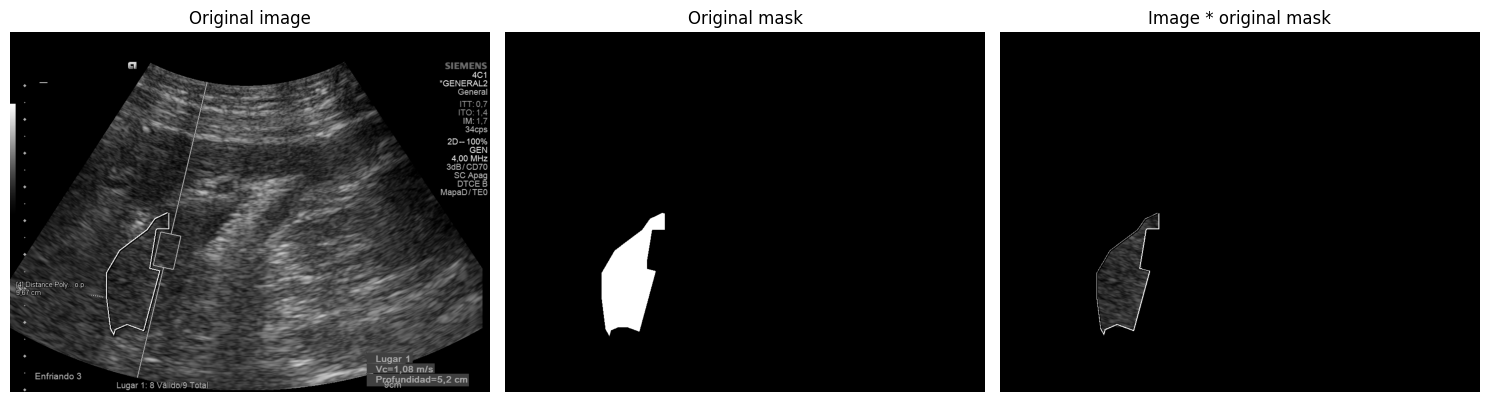

In [37]:
# apply current mask
masked_before = image_rgb * mask_bin[:, :, None]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image_rgb)
ax[0].set_title('Original image')
ax[0].axis('off')

ax[1].imshow(mask_bin, cmap='gray')
ax[1].set_title('Original mask')
ax[1].axis('off')

ax[2].imshow(masked_before)
ax[2].set_title('Image * original mask')
ax[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# reduce mask a bit with erosion
kernel_size = 9   # try 3, 5, 7
iterations = 1    # try 1 or 2

kernel = np.ones((kernel_size, kernel_size), np.uint8)
mask_eroded = cv2.erode(mask_bin, kernel, iterations=iterations)

masked_after = image_rgb * mask_eroded[:, :, None]

print('kernel_size:', kernel_size)
print('iterations :', iterations)
print('pixels in original mask:', int(mask_bin.sum()))
print('pixels in eroded mask  :', int(mask_eroded.sum()))

kernel_size: 10
iterations : 1
pixels in original mask: 18933
pixels in eroded mask  : 15255


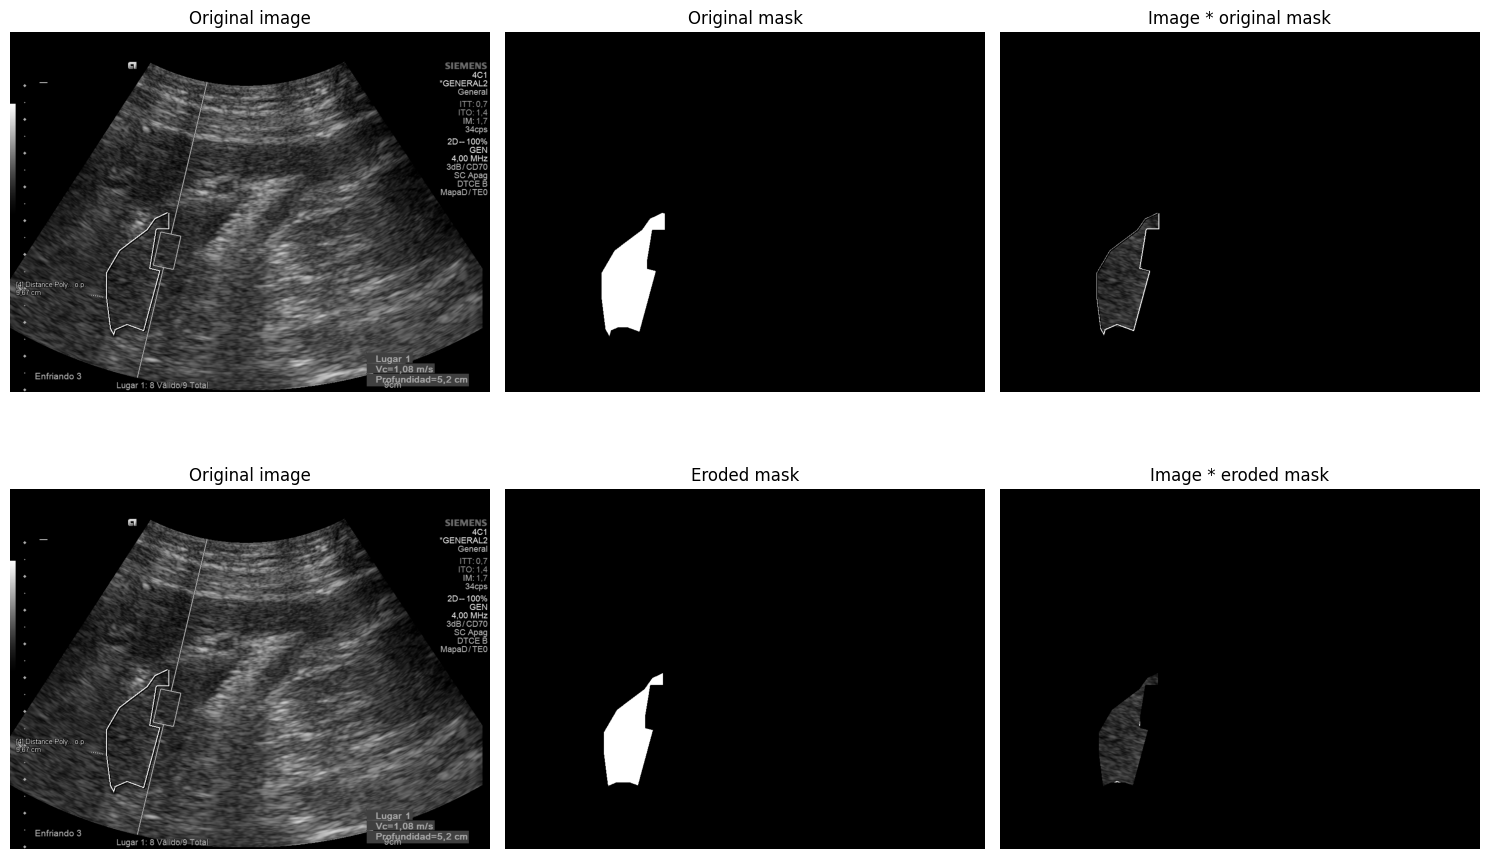

In [49]:
# compare before vs after erosion
fig, ax = plt.subplots(2, 3, figsize=(15, 10))

ax[0, 0].imshow(image_rgb)
ax[0, 0].set_title('Original image')
ax[0, 0].axis('off')

ax[0, 1].imshow(mask_bin, cmap='gray')
ax[0, 1].set_title('Original mask')
ax[0, 1].axis('off')

ax[0, 2].imshow(masked_before)
ax[0, 2].set_title('Image * original mask')
ax[0, 2].axis('off')

ax[1, 0].imshow(image_rgb)
ax[1, 0].set_title('Original image')
ax[1, 0].axis('off')

ax[1, 1].imshow(mask_eroded, cmap='gray')
ax[1, 1].set_title('Eroded mask')
ax[1, 1].axis('off')

ax[1, 2].imshow(masked_after)
ax[1, 2].set_title('Image * eroded mask')
ax[1, 2].axis('off')

plt.tight_layout()
plt.show()